# **Sistema de Alerta Temprana de Dengue** 

**Predicción de brotes epidemiológicos con 4 semanas de antelación mediante Machine Learning y Pipelines de Datos Automatizados.**

**Framework de Machine Learning Escalable para la Vigilancia Epidemiológica del Dengue en Colombia**

## **Resumen Ejecutivo** 📋

El Dengue es una enfermedad endémica que presiona cíclicamente los sistemas de salud en Colombia. La reacción tardía cuesta recursos y vidas.

Este proyecto implementa un **pipeline de ingeniería de datos end-to-end** que ingesta datos epidemiológicos (SIVIGILA) y climáticos (Open-Meteo), los procesa automáticamente y entrena un modelo XGBoost capaz de predecir el número de casos esperados en la ciudad de Cali.

**Impacto: Permite a las autoridades de salud pasar de un modelo reactivo a uno preventivo, optimizando la gestión de camas UCI y suministros médicos.**

## **Arquitectura del Sistema**

**El proyecto no es un simple análisis estático, sino una arquitectura de datos escalable y automatizada.**

In [ ]:
graph LR
    A[SIVIGILA API] -->|Extracción Histórica| C(Python ETL Scripts)
    B[Open-Meteo API] -->|Clima Diario| C
    C -->|Limpieza & Transformación| D[(Master Dataset .parquet)]
    D -->|Feature Engineering| E[XGBoost Model]
    E -->|Predicción Recursiva| F[Output CSV]
    F -->|Visualización| G[Tableau Dashboard]
    H[GitHub Actions] -.->|Orquestación Semanal| C

## **Componentes Clave:**

- **Ingeniería de Datos:** 
Scripts modulares en Python (src/data_engineering) que se conectan a APIs gubernamentales (Socrata) y globales. Manejo robusto de errores, tipos de datos y "retries".

- **Almacenamiento:** 
Uso de formato Parquet para eficiencia en almacenamiento y lectura de tipos de datos.

- **Modelado:** 
Modelo de regresión XGBoost optimizado para series temporales.

- **Automatización:** 
Flujo CI/CD con GitHub Actions que ejecuta el pipeline semanalmente.

## **Ciencia de Datos y Modelado** 

### **El Reto de los Datos**

Durante la fase de exploración, identificamos que la lluvia no genera casos inmediatos. Descubrimos un "Efecto Lavado": las lluvias fuertes tienen una correlación negativa inmediata (-0.36), mientras que las condiciones ideales para el mosquito generan un pico de casos con un retraso (lag) de 4 a 6 semanas.

### **Ingeniería de Características (Feature Engineering)**

**Para capturar esta complejidad biológica, transformamos 5 variables base en más de 20 features predictivas:**

- **Lags Temporales:** Lluvia y temperatura de hace 1, 2, 3 y 4 semanas.

- **Ventanas Móviles:** Acumulados de precipitación y promedios de temperatura.

- **Variables de Inercia:** Autocorrelación de casos previos (el mejor predictor).

### **Resultados del Modelo**

**El modelo fue validado con datos fuera de muestra (Out-of-Time testing):**

- **MAE (Error Absoluto Medio):** ~10 casos por semana.

- **Capacidad de Detección:** El modelo identificó correctamente el inicio y el pico del brote epidémico de finales de 2022.

## ⚠️ **Estado de los Datos y Actualización Automática**

Actualmente, el modelo está entrenado con datos históricos auditados hasta **Diciembre de 2022**.

### **¿Por qué no hay datos de 2023-2025?**

El Sistema Nacional de Vigilancia (SIVIGILA) opera con dos tipos de datos:
1.  **Preliminares:** Datos en tiempo real sujetos a ajustes semanales.
2.  **Auditados (Históricos):** Datos finales, depurados y validados legalmente.

El dataset maestro oficial (`4hyg-wa9d`) utilizado en este proyecto contiene únicamente los datos **auditados**, los cuales tienen un rezago natural de publicación de 1-2 años por parte del Instituto Nacional de Salud.

### 🔄 **Arquitectura "Future-Proof" (A prueba de futuro)**

Este repositorio ha sido diseñado para resolver este problema automáticamente. No es un análisis estático, sino un pipeline vivo:

* **Automatización:** El flujo de GitHub Actions consulta la API de Socrata semanalmente.
* **Auto-Actualización:** En el momento en que el INS libere los datos oficiales de 2023, 2024 o 2025 al dataset histórico, el sistema los detectará, los descargará y **re-entrenará el modelo automáticamente** sin intervención 
humana.

### **Nota:**

- **En el archivo 05_Experiment_Climate_Only.ipynb hice un experimento interesante prediciendo los casos de Dengue 2023 - 2025 usando Unicamente los datos climaticos de estos años, el experimento fue un exito demostrando que el modelo es preciso y funciona.**

## 🌍 **Escalabilidad y Reproducibilidad (Multi-Ciudad)** 

**Una de las fortalezas principales de este repositorio es su diseño modular. No está "hard-coded" para Cali.**

**Este proyecto ha sido diseñado con una arquitectura modular que permite desplegar el modelo en cualquier ciudad de Colombia en cuestión de minutos.**

La lógica del código está separada de los parámetros de configuración.

Toda la configuración reside en **config.yaml.** Desplegar el modelo en una nueva ciudad **(ej. Medellín)** toma menos de 5 minutos:

In [ ]:
# config.yaml
target_city:
  name: "MEDELLIN"   # Filtro automático para API SIVIGILA
  lat: 6.24          # Coordenadas para API Clima
  lon: -75.57

### El **pipeline** lee esta configuración y adapta automáticamente las consultas **SQL** y las peticiones climáticas.

## 📊 **Dashboard de Control**

- La salida final es un tablero de control estratégico en Tableau diseñado para la toma de decisiones rápida.

- **Semáforo de Riesgo:** Alerta automatizada basada en umbrales epidémicos.

- **Proyección:** Línea continua (historia) vs. Línea punteada (predicción IA).

**Enlace para verlo en Tableau Public:** [https://public.tableau.com/app/profile/diego.ortiz3976/viz/Libro1_17637397482790/Dashboard1]

![Dashboard 1.png](<attachment:Dashboard 1.png>)
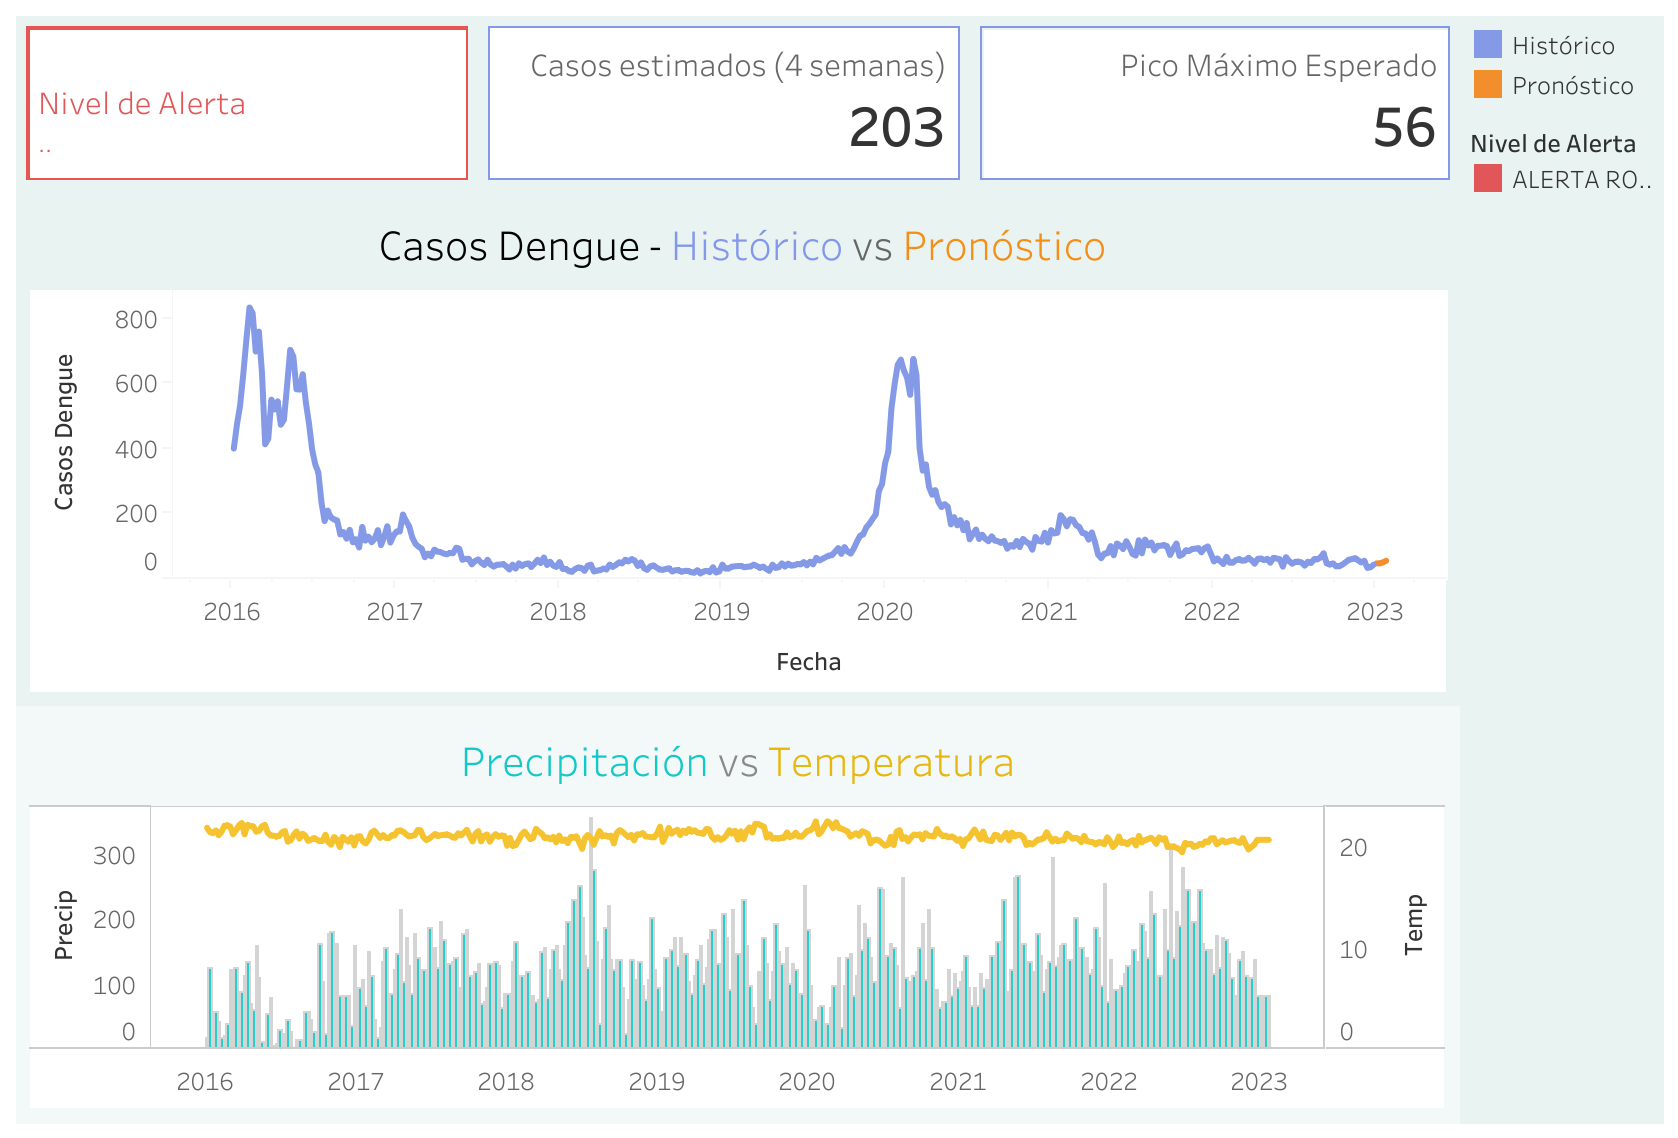

## **Stack Tecnológico**

- **Lenguaje:** Python 3.13.1

- **ETL & Data Manipulation:** Pandas, Sodapy (Socrata API Client), Requests.

- **Machine Learning:** XGBoost, Scikit-Learn.

- **Orquestación:** GitHub Actions (Cron Jobs).

- **Formato de Datos:** Parquet, CSV.

- **Visualización:** Matplotlib, Seaborn (Exploración), Tableau Public (Producción).

## **Cómo ejecutar este proyecto localmente**

**1. Clonar el repositorio:**

In [ ]:
git clone https://github.com/tu-usuario/dengue-early-warning.git
cd dengue-early-warning

**2. Instalar dependencias:**

In [ ]:
pip install -r requirements.txt

**3. Ejecutar el Pipeline de Ingeniería:**

In [ ]:
# Descarga datos climáticos y epidemiológicos
python src/data_engineering/01_get_climate_data.py
python src/data_engineering/02_get_sivigila_data.py

**4. Generar Predicciones:**

In [ ]:
# Procesa, entrena y exporta el resultado para Tableau
python src/modeling/04_predict.py

## 👨‍💻 **Autor**:

### **Diego Ortiz - Analitics Engineer & Data Ops**

[Link a tu LinkedIn] | [Link a tu Portafolio]